# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RajatBharti11/Rajat/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

For a subscription service, predicting **customer churn** is a critical business problem.

This task is a **classification** problem. We aim to predict a binary outcome: whether a customer will cancel their subscription (churn) or continue (retain).

In [13]:
import pandas as pd
import numpy as np

# Seed for reproducibility
np.random.seed(42)

# Generate synthetic data for customer churn prediction
num_customers = 1000

data = {
    'customer_id': range(1, num_customers + 1),
    'subscription_duration_days': np.random.randint(30, 730, num_customers), # 1 month to 2 years
    'monthly_bill': np.random.uniform(10, 100, num_customers).round(2),
    'data_usage_gb': np.random.uniform(5, 500, num_customers).round(1),
    'support_tickets_last_30_days': np.random.randint(0, 5, num_customers),
    'last_login_days_ago': np.random.randint(0, 90, num_customers),
    'churn': np.random.choice([0, 1], num_customers, p=[0.85, 0.15]) # 15% churn rate
}

df = pd.DataFrame(data)

print("Synthetic customer data generated and loaded into DataFrame 'df'.")


Synthetic customer data generated and loaded into DataFrame 'df'.


In [14]:
print(f"The ML task type is Classification, as indicated by the binary 'churn' target variable.")
print("Churn Distribution:")
display(df['churn'].value_counts())

The ML task type is Classification, as indicated by the binary 'churn' target variable.
Churn Distribution:


,count
churn,
0,869
1,131


The **target** we would predict is a binary variable representing `churn` (1 for churn, 0 for retention). This label comes directly from the **observed outcome** of a customer canceling their subscription.

## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

In [15]:
print(f"The target variable is 'churn', which is a binary outcome (0 = retention, 1 = churn).")
print("Target variable (churn) head:")
display(df[['customer_id', 'churn']].head())

The target variable is 'churn', which is a binary outcome (0 = retention, 1 = churn).
Target variable (churn) head:


,customer_id,churn
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


The primary **success metric** would be **Recall** for the churn class. This metric is chosen because identifying customers at risk of churning is often more valuable than accurately identifying loyal customers. A high recall ensures that we capture a significant portion of actual churners, allowing for proactive interventions (e.g., special offers, support outreach) to prevent them from leaving. Minimizing false negatives (missing actual churners) is prioritized over minimizing false positives (incorrectly identifying a loyal customer as a churner, which might only result in a small, unnecessary intervention).

## 3. Success metric

*One metric you can defend. What number means 'good'?*

In [16]:
from sklearn.metrics import recall_score

# Placeholder for a hypothetical model's predictions and true labels
true_labels = np.array([0, 1, 0, 1, 1, 0, 1, 0, 0, 1])
predicted_labels = np.array([0, 1, 0, 0, 1, 0, 1, 0, 1, 1]) # Example: missed one churner, falsely predicted one churner

recall = recall_score(true_labels, predicted_labels)
print(f"Example Recall (for churn class): {recall:.2f}")
print("A high recall (e.g., > 0.75) would indicate a 'good' model, prioritizing the identification of actual churners.")

Example Recall (for churn class): 0.80
A high recall (e.g., > 0.75) would indicate a 'good' model, prioritizing the identification of actual churners.


The **unit of analysis** is a single **customer** at a specific point in time. Each row in our dataframe will represent one customer and their associated features that could influence churn.

## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

In [17]:
import pandas as pd
import numpy as np

# Seed for reproducibility
np.random.seed(42)

# Generate synthetic data for customer churn prediction
num_customers = 1000

data = {
    'customer_id': range(1, num_customers + 1),
    'subscription_duration_days': np.random.randint(30, 730, num_customers), # 1 month to 2 years
    'monthly_bill': np.random.uniform(10, 100, num_customers).round(2),
    'data_usage_gb': np.random.uniform(5, 500, num_customers).round(1),
    'support_tickets_last_30_days': np.random.randint(0, 5, num_customers),
    'last_login_days_ago': np.random.randint(0, 90, num_customers),
    'churn': np.random.choice([0, 1], num_customers, p=[0.85, 0.15]) # 15% churn rate
}

df = pd.DataFrame(data)

print("Unit of analysis: Each row represents a unique customer.")
display(df.head())

print("\nSketch of the target column ('churn'):")
display(df[['customer_id', 'churn']].head())

Unit of analysis: Each row represents a unique customer.


,customer_id,subscription_duration_days,monthly_bill,data_usage_gb,support_tickets_last_30_days,last_login_days_ago,churn
0,1,132,43.92,210.0,3,55,0
1,2,465,51.64,414.6,0,59,0
2,3,300,37.12,368.1,0,9,0
3,4,136,77.28,385.8,2,38,0
4,5,101,55.24,10.5,1,27,0



Sketch of the target column ('churn'):


,customer_id,churn
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [18]:
print("Detailed information about the unit of analysis (customer dataframe):")
df.info()

Detailed information about the unit of analysis (customer dataframe):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   1000 non-null   int64  
 1   subscription_duration_days    1000 non-null   int64  
 2   monthly_bill                  1000 non-null   float64
 3   data_usage_gb                 1000 non-null   float64
 4   support_tickets_last_30_days  1000 non-null   int64  
 5   last_login_days_ago           1000 non-null   int64  
 6   churn                         1000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 54.8 KB


Predicting customer churn is a complex problem that **ML beats a fixed rule** because a customer's decision to churn is influenced by a multitude of interacting factors that are difficult, if not impossible, to capture with simple `if-else` statements. These factors include:

*   **Usage patterns**: Changes in data consumption, login frequency, or feature utilization can be subtle indicators.
*   **Billing history**: Payment issues, changes in subscription costs, or promotional periods expiring.
*   **Customer support interactions**: Frequency, sentiment, and resolution time of support tickets.
*   **Demographic and behavioral data**: Customer tenure, plan type, and engagement with the service.

A fixed rule would likely be either too rigid, leading to many missed churners (low recall) or too broad, flagging many loyal customers unnecessarily (low precision). An ML model, however, can learn non-linear relationships and interactions between these features, adapt to evolving customer behavior, and provide probabilistic predictions, making it far more effective at identifying customers at risk of churning.

## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

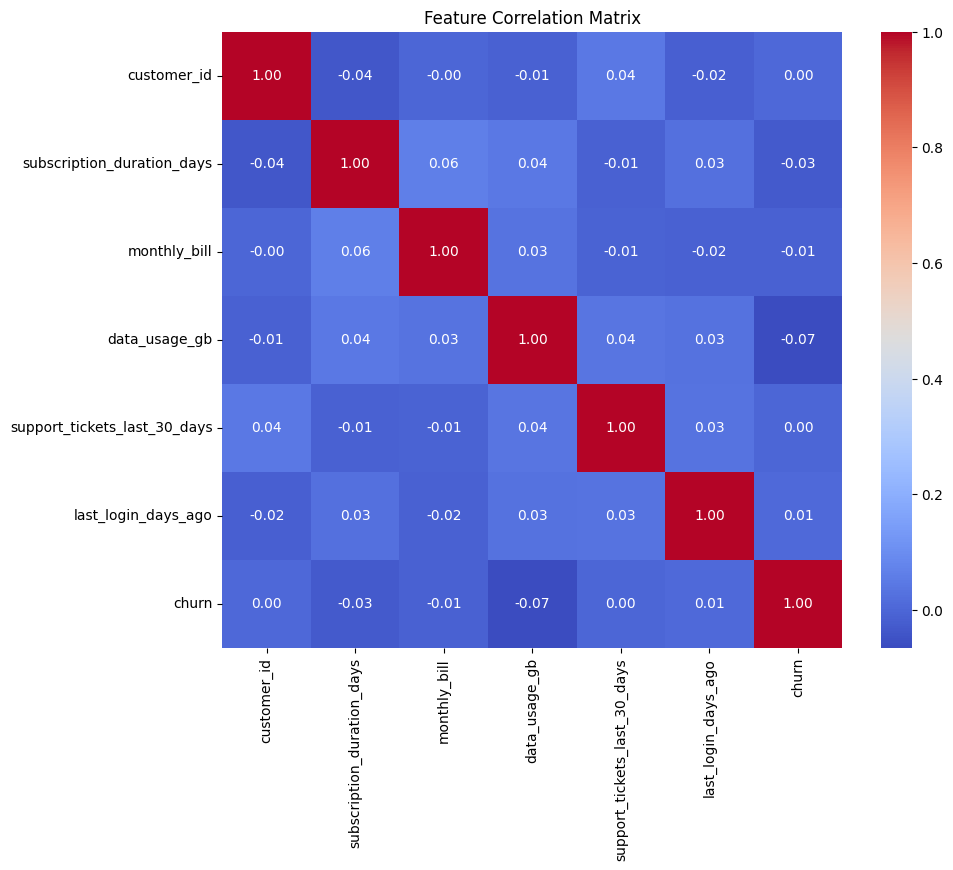

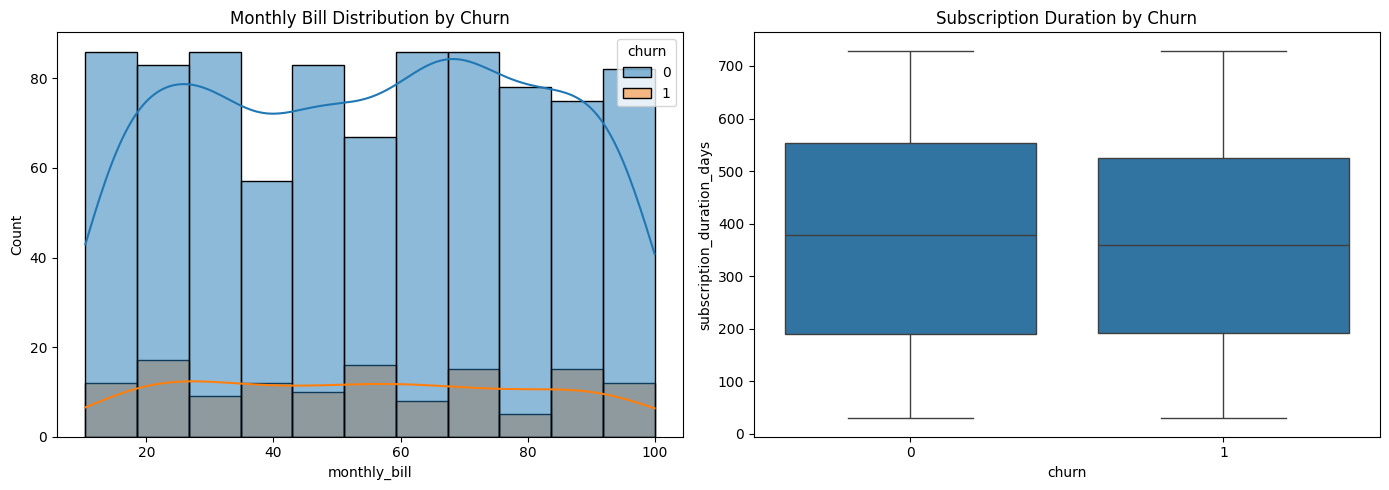

The complex interplay and non-linear relationships visible in these distributions and correlations demonstrate why a simple rule-based system would be inadequate and why ML is needed.


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

# Example of a feature distribution against churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='monthly_bill', hue='churn', kde=True, ax=axes[0])
axes[0].set_title('Monthly Bill Distribution by Churn')
sns.boxplot(data=df, x='churn', y='subscription_duration_days', ax=axes[1])
axes[1].set_title('Subscription Duration by Churn')
plt.tight_layout()
plt.show()

print("The complex interplay and non-linear relationships visible in these distributions and correlations demonstrate why a simple rule-based system would be inadequate and why ML is needed.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.